# **External validation on LGMR product**

In [2]:
from geostat_isoscapes_tools import utils,plot_utils
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy import odr
def linear_model(B, x):
    return B[0]*x+B[1]

**First, let us load the dataset (adapt the code to the local path to this dataset)**

In [3]:
lgmr_data= utils.load_xarray_datarray('/media/luluxette/T7_Shield/pdm/LGMR_d18Op_climo.nc')
# keep only the ages between 11 and 20 ka BP form this xarray
lgmr_data = lgmr_data.sel(age=slice(11000, 20000))
# convert to df
lgmr_data_df = lgmr_data.to_dataframe().reset_index()
# convert to pos-neg longitudes
lgmr_data_df['lon']=utils.convert_lon_0_360_to_neg180_180(np.asarray(lgmr_data_df.lon))

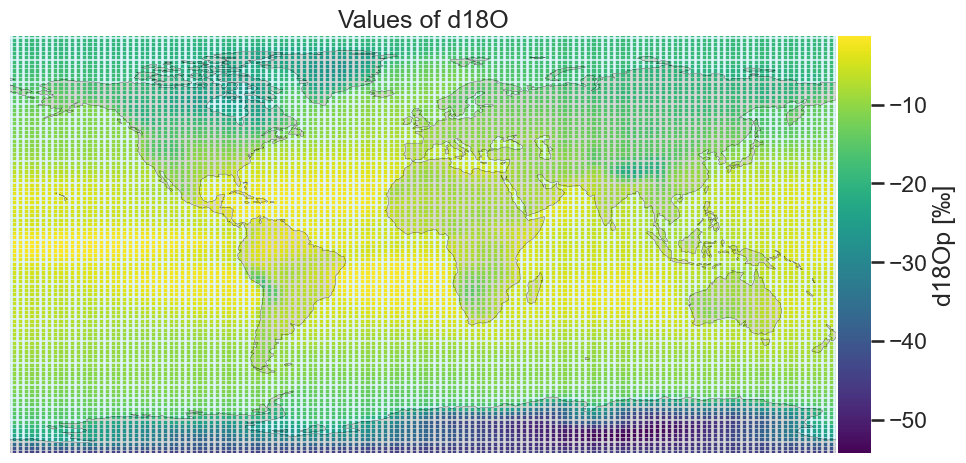

In [ ]:
fig,ax = plot_utils.plot_latlon_platecarree_df(lgmr_data_df[lgmr_data_df.age==11100.0],s=5)

In [4]:
print(lgmr_data_df.age.unique())

[11100. 11300. 11500. 11700. 11900. 12100. 12300. 12500. 12700. 12900.
 13100. 13300. 13500. 13700. 13900. 14100. 14300. 14500. 14700. 14900.
 15100. 15300. 15500. 15700. 15900. 16100. 16300. 16500. 16700. 16900.
 17100. 17300. 17500. 17700. 17900. 18100. 18300. 18500. 18700. 18900.
 19100. 19300. 19500. 19700. 19900.]


Compute the error metrics (MAE, RMSE, R2) between the LGMR data and the kriged predictions at these points



In [5]:
# 1. load the kriged product
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/runs_wip/2026-06-04/res200/speleothems_isoscapes_11_to_20kaBP.nc')
kriged_df = kriged_ds.to_dataframe().reset_index()
# kriged_df = kriged_df[kriged_df.confidence_flag<3]

In [6]:
kriged_df.d18Op.describe()

count    281900.000000
mean        -21.775168
std          17.865957
min         -84.548863
25%         -29.595016
50%         -16.807822
75%          -7.442173
max           2.957156
Name: d18Op, dtype: float64

In [6]:
# 2. Construct a dataframe with the kriged values and the corresponding LGMR values at the same location and time 

# Each bin [t, t+200] of the kriged_df overlaps 50% with the bin [t-100, t+100] and 50% with the bin [t+100, t+300] of the LGMR dataframe.
df_A = kriged_df.rename(columns={"time": "time_A", "d18Op": "d18Op_A"})
df_B = lgmr_data_df.rename(columns={"age": "time_B", "d18Op": "d18Op_B"})

df_B["time_A_lo"] = df_B["time_B"] - 100
df_B["time_A_hi"] = df_B["time_B"] + 100 
df_merged = (df_B.merge(df_A.rename(columns={"time_A": "time_A_lo", "d18Op_A": "d18Op_A_lo"}), on=["lat", "lon", "time_A_lo"], how="inner").merge(df_A.rename(columns={"time_A": "time_A_hi", "d18Op_A": "d18Op_A_hi"}),on=["lat", "lon", "time_A_hi"], how="inner"))
# Overlap-weighted mean:
df_merged["d18Op_A_aligned"] = 0.5 * df_merged["d18Op_A_lo"] + 0.5 * df_merged["d18Op_A_hi"]

df_comparison = df_merged[["lat", "lon", "time_B", "d18Op_A_aligned", "d18Op_B"]].copy()
df_comparison.rename(columns={"time_B": "time", "d18Op_B": "d18Op_LGMR", "d18Op_A_aligned": "d18Op_kriged"},inplace=True)

In [7]:
df_comparison['bias']=df_comparison['d18Op_kriged']-df_comparison['d18Op_LGMR']
df_comparison['diff_norm']=df_comparison['bias']/np.abs(df_comparison['d18Op_LGMR'])
df_comparison['rmsd']=np.sqrt((df_comparison['bias'])**2)

In [8]:
df_comparison.dropna(subset=['d18Op_kriged', 'd18Op_LGMR'], inplace=True)

In [9]:
df_comparison.diff_norm.describe()

count    275480.000000
mean          0.027663
std           0.254233
min          -0.821155
25%          -0.129766
50%          -0.010184
75%           0.167398
max           2.608770
Name: diff_norm, dtype: float64

0.9839587887283459 0.0


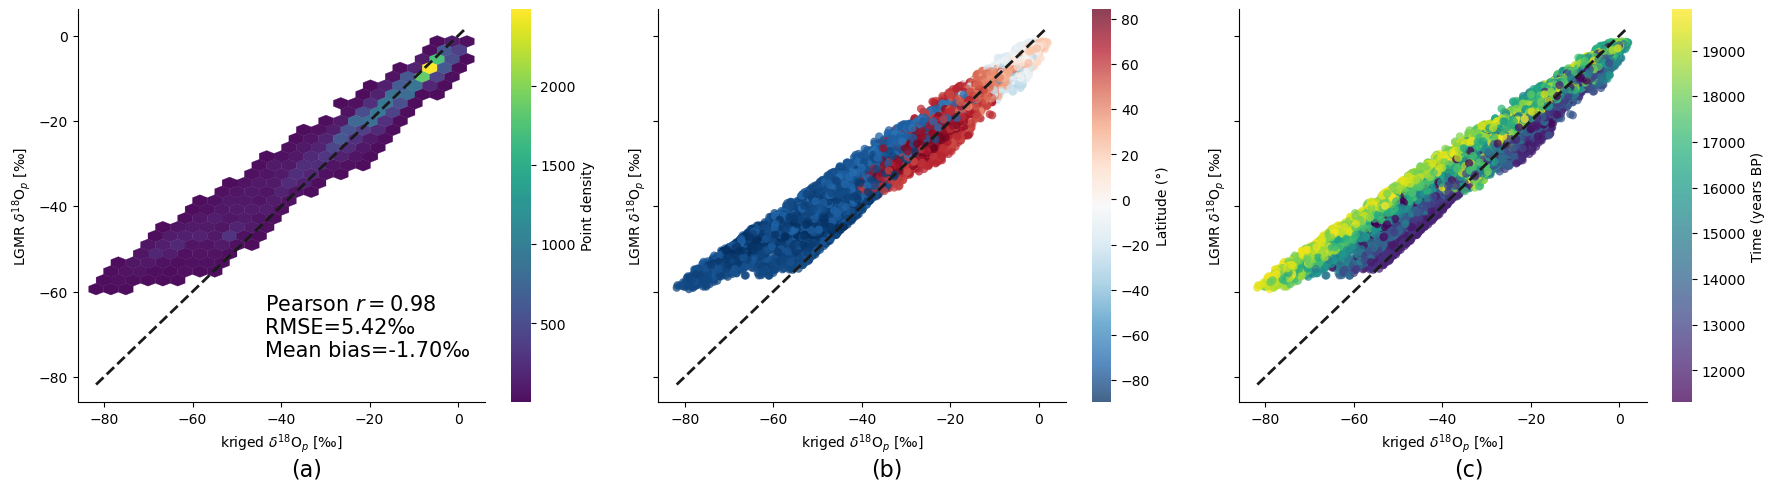

In [17]:
# df = df_comparison[df_comparison.time.between(11000, 12000)]
# define df as a random sample of 5000 points from df comparison 
df = df_comparison.sample(n=30000, random_state=42)
x = 'd18Op_kriged'
y = 'd18Op_LGMR'

# metrics
r, p_value = pearsonr(df[x], df[y])
print(r,p_value)
rmse = utils.RMSE(df[x], df[y])
bias = np.mean(df[x]-df[y])

# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
ax_density, ax_scatter, ax_time = axes

# Left: density plot (as previously implemented)
hb = ax_density.hexbin(
    df[x],
    df[y],
    gridsize=25,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,
)
cbar = fig.colorbar(hb, ax=ax_density, label='Point density')
cbar.outline.set_visible(False)
# Right: scatter plot colored by latitude (diverging colormap)
sc = ax_scatter.scatter(
    df[x],
    df[y],
    c=df['lat'],
    cmap='RdBu_r',
    s=35,
    alpha=0.75,
    edgecolors='none',
)
cbar = fig.colorbar(sc, ax=ax_scatter, label='Latitude (°)')
cbar.outline.set_visible(False)

# right : scatter plot colored by time
sc_time = ax_time.scatter(
    df[x],
    df[y],
    c=df['time'],
    cmap='viridis',
    s=35,
    alpha=0.75,
    edgecolors='none',
)
cbar = fig.colorbar(sc_time, ax=ax_time, label='Time (years BP)')
cbar.outline.set_visible(False)

# reference line and common layout
min_val = min(df[x].min(), df[y].min())
max_val = max(df[x].max(), df[y].max())
n = ['(a)', '(b)', '(c)']
for ax,n in zip(axes, n):
    ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, color='0.1', label='1:1 line')
    ax.text(0.6, -0.2, n, transform=ax.transAxes, fontsize=16, va='bottom', ha='right')
    ax.set_xlabel(r'kriged $\delta^{18}$O$_p$ [‰]')
    ax.set_ylabel(r'LGMR $\delta^{18}$O$_p$ [‰]')
    # ax.set_title(r'kriged vs LGMR $\delta^{18}$O', pad=8)
    sns.despine(ax=ax)

# ax_density.set_title(r'Kriged vs LGMR density' '\n' f'N={len(df):.2e}', pad=8)
# ax_scatter.set_title(r'Kriged vs LGMR by latitude' '\n' f'N={len(df):.2e}', pad=8)

fig.text(0.15, 0.4,
    fr'Pearson $r={r:.2f}$' '\n'
    fr'RMSE={rmse:.2f}‰' '\n'
    r'Mean bias=' f'{bias:.2f}‰', #$\delta^{18}O_{kriged}-\delta^{18}O_{LGMR}
    va='top', ha='left', fontsize=15,
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9))

fig.tight_layout()
plt.savefig('../output/essd_figs/fig_LGMR.png', dpi=500, bbox_inches='tight')
plt.show()
